In [1]:
# Import các thư viện phân tích và trực quan hóa dữ liệu cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style mặc định cho các biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# 1. Nạp dữ liệu
file_path = 'd:/2nd Term of Junior/KHDL/de_tai_2_headphone/clean_data/headphone_clean.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Đã tải thành công tập dữ liệu với {df.shape[0]} dòng và {df.shape[1]} cột.")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")

# 2. Xem trước cấu trúc dữ liệu
display(df.head())
display(df.info())

Đã tải thành công tập dữ liệu với 1026 dòng và 13 cột.


,source,url,name,price_raw,price_vnd,brand,type,is_gaming,is_wireless,has_mic,connection,battery_life_hours,weight_gram
0,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-so...,Tai nghe Bluetooth chụp tai Sony WH-1000XM6,11.990.000đ,11990000,Sony,over-ear,0,1,0,3.5mm,40.0,254.0
1,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-se...,Tai nghe chụp tai Sennheiser HDB 630,14.900.000đ,14900000,Sennheiser,over-ear,0,0,0,NaN,60.0,NaN
2,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-so...,Tai nghe Bluetooth chụp tai Sony WH-1000XM5,7.990.000đ,7990000,Sony,over-ear,0,1,0,3.5mm,NaN,40.0
3,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-so...,Tai nghe Bluetooth chụp tai Sony WH-CH520,1.290.000đ,1290000,Sony,over-ear,0,1,0,NaN,50.0,40.0
4,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-jb...,Tai nghe Bluetooth chụp tai JBL Tune 520BT,1.360.000đ,1360000,JBL,over-ear,0,1,0,Type C,57.0,157.0


<class 'pandas.DataFrame'>
RangeIndex: 1026 entries, 0 to 1025
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   source              1026 non-null   str    
 1   url                 1026 non-null   str    
 2   name                1026 non-null   str    
 3   price_raw           1021 non-null   str    
 4   price_vnd           1026 non-null   int64  
 5   brand               1026 non-null   str    
 6   type                269 non-null    str    
 7   is_gaming           1026 non-null   int64  
 8   is_wireless         1026 non-null   int64  
 9   has_mic             1026 non-null   int64  
 10  connection          231 non-null    str    
 11  battery_life_hours  339 non-null    float64
 12  weight_gram         344 non-null    float64
dtypes: float64(2), int64(4), str(7)
memory usage: 104.3 KB


None

In [3]:
# 3. Thống kê mô tả các biến số
display(df.describe(include=[np.number]))

# 4. Kiểm tra số lượng giá trị phân biệt (Cardinality) của các biến phân loại
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Số giá trị phân biệt của '{col}': {df[col].nunique()}")

,price_vnd,is_gaming,is_wireless,has_mic,battery_life_hours,weight_gram
count,1.026000e+03,1026.000000,1026.000000,1026.000000,339.000000,344.000000
mean,3.838804e+06,0.164717,0.519493,0.010721,23.091445,105.247965
std,8.711232e+06,0.371106,0.499864,0.103037,28.595121,155.768679
min,0.000000e+00,0.000000,0.000000,0.000000,2.000000,0.200000
25%,6.500000e+05,0.000000,0.000000,0.000000,7.000000,5.200000
50%,1.750000e+06,0.000000,1.000000,0.000000,9.000000,16.695000
75%,5.000000e+06,0.000000,1.000000,0.000000,30.000000,222.000000
max,1.689900e+08,1.000000,1.000000,1.000000,240.000000,1650.000000


Số giá trị phân biệt của 'source': 3
Số giá trị phân biệt của 'url': 1026
Số giá trị phân biệt của 'name': 1024
Số giá trị phân biệt của 'price_raw': 405
Số giá trị phân biệt của 'brand': 108
Số giá trị phân biệt của 'type': 2
Số giá trị phân biệt của 'connection': 4


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15664\1067483353.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [4]:
# Khảo sát tỷ lệ missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Total Missing': missing_data, 'Percentage (%)': missing_percent})
display(missing_df[missing_df['Total Missing'] > 0].sort_values(by='Percentage (%)', ascending=False))

,Total Missing,Percentage (%)
connection,795,77.485380
type,757,73.781676
battery_life_hours,687,66.959064
weight_gram,682,66.471735
price_raw,5,0.487329


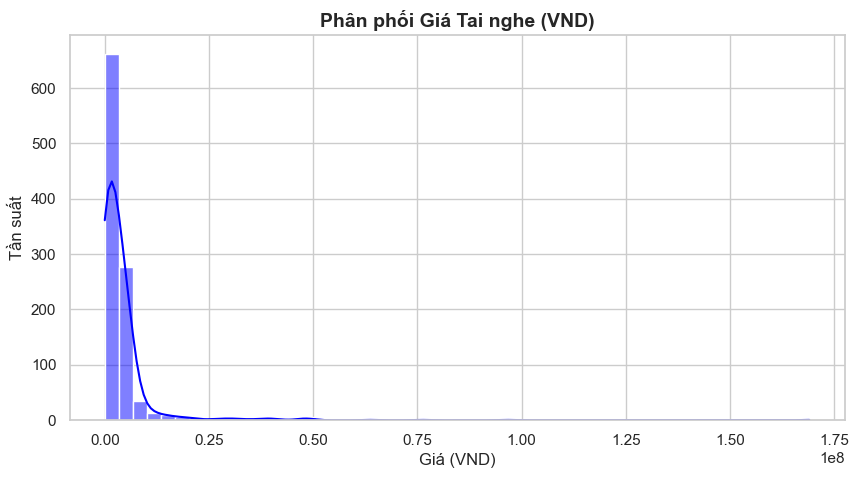

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price_vnd'].dropna(), bins=50, kde=True, color='blue')
plt.title("Phân phối Giá Tai nghe (VND)", fontsize=14, fontweight='bold')
plt.xlabel("Giá (VND)")
plt.ylabel("Tần suất")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15664\256848133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='price_vnd', palette='Set2')


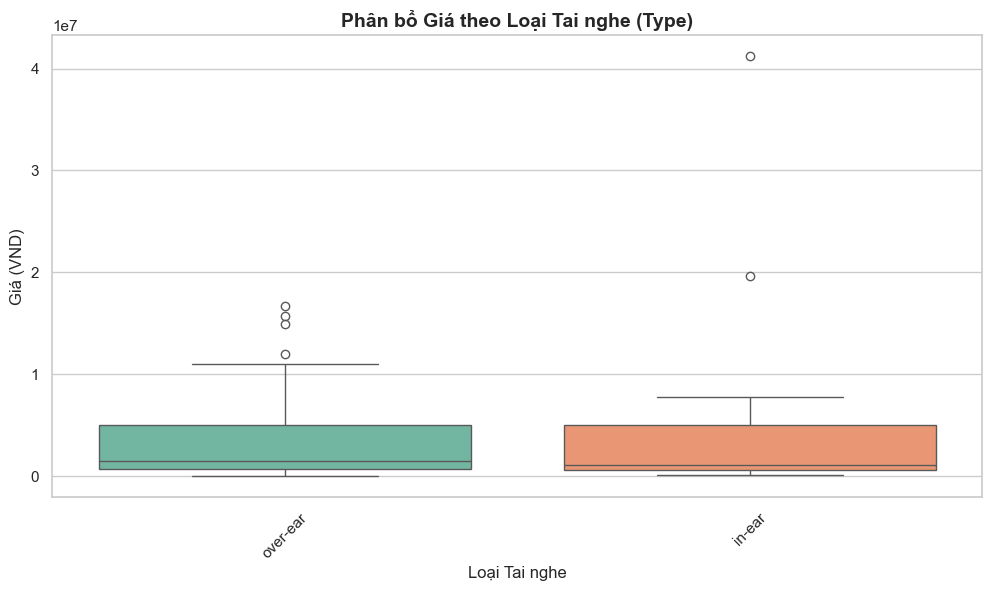

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='type', y='price_vnd', palette='Set2')
plt.title("Phân bổ Giá theo Loại Tai nghe (Type)", fontsize=14, fontweight='bold')
plt.xlabel("Loại Tai nghe")
plt.ylabel("Giá (VND)")
plt.xticks(rotation=45)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15664\1763658184.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')


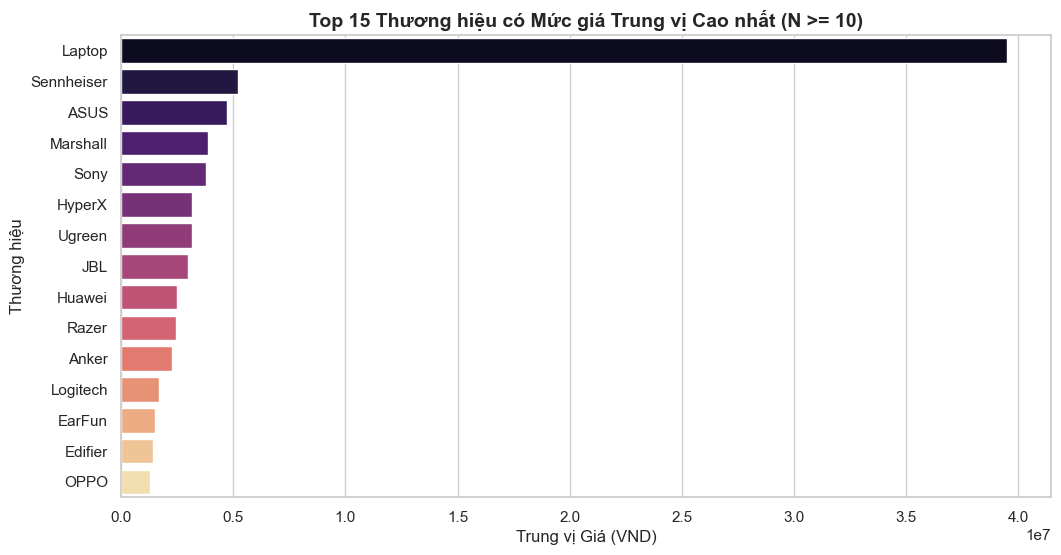

In [7]:
# Lọc các thương hiệu có >= 10 sản phẩm
brand_counts = df['brand'].value_counts()
valid_brands = brand_counts[brand_counts >= 10].index
df_valid_brands = df[df['brand'].isin(valid_brands)]

# Tính trung vị giá và chọn Top 15
top_brands = df_valid_brands.groupby('brand')['price_vnd'].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')
plt.title("Top 15 Thương hiệu có Mức giá Trung vị Cao nhất (N >= 10)", fontsize=14, fontweight='bold')
plt.xlabel("Trung vị Giá (VND)")
plt.ylabel("Thương hiệu")
plt.show()

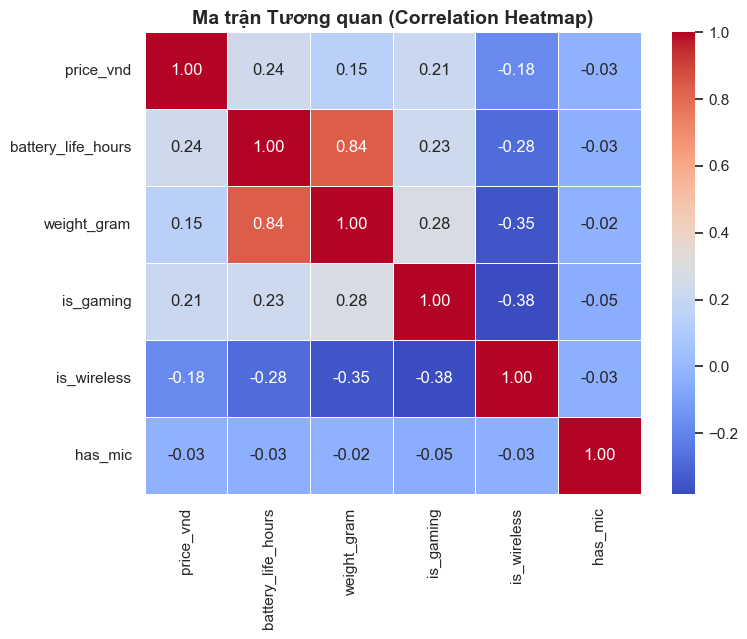

In [8]:
# Lọc các cột Numeric và Boolean để tính tương quan
num_cols = ['price_vnd', 'battery_life_hours', 'weight_gram', 'is_gaming', 'is_wireless', 'has_mic']
num_cols = [c for c in num_cols if c in df.columns]

# Khởi tạo ma trận tương quan Pearson
corr_matrix = df[num_cols].corr()

# Trực quan hóa bằng Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Ma trận Tương quan (Correlation Heatmap)", fontsize=14, fontweight='bold')
plt.show()